<a href="https://colab.research.google.com/github/DeepthiManthapuram/Celebal_Excellence_Internship/blob/main/week2_Deepthi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **End-to-end ML pipeline on sales/price data.**

# End-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

In [64]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Loading

In [65]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/tesla_deliveries_dataset_2015_2025.csv")
df.head(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


# Dataset Understanding

This dataset contains Tesla EV market data from different regions and years. It includes delivery estimates, production figures, vehicle specifications, pricing information, environmental impact metrics, and charging infrastructure data.

Each row represent:
1) A specific Tesla model
2) In a specific region
3) During a specific month and year

# Problem Statement

The objective of this project is to predict EV demand (Estimated Deliveries) using production, pricing, vehicle specifications, and regional factors. The project also aims to forecast future delivery trends and identify factors influencing demand.

# **Data Preprocessing**
Inspecting Data Quality

In [66]:
#Dataset shape
df_shape = df.shape
print("Shape of dataset: ", df_shape)
print("Number of rows in dataset: ", df_shape[0])
print("Number of columns in dataset: ", df_shape[1])

Shape of dataset:  (2640, 12)
Number of rows in dataset:  2640
Number of columns in dataset:  12


In [67]:
#columns in the datasets
cols = df.columns
cols

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [68]:
#Data types of each column
df.dtypes

,0
Year,int64
Month,int64
Region,object
Model,object
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64


In [69]:
#Extracting Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:")
for i in num_cols:
  print(i)


Numerical columns:
Year
Month
Estimated_Deliveries
Production_Units
Avg_Price_USD
Battery_Capacity_kWh
Range_km
CO2_Saved_tons
Charging_Stations


In [70]:
#Extracting Categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:")
for i in cat_cols:
  print(i)


Categorical columns:
Region
Model
Source_Type


In [71]:
#Missing values
missing_values_sum = df.isna().sum()
print("Number of missing values in each column:")
missing_values_sum

Number of missing values in each column:


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


There are no missing values in the dataset.

In [72]:
#Null values
null_values_sum = df.isnull().sum()
print("Number of null values in each column: ")
null_values_sum

Number of null values in each column: 


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


There are no null values in the dataset.

In [73]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2635,False
2636,False
2637,False
2638,False


There are no duplicate values in the dataset.

In [74]:
#Descriptive Statistics
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


#Univariate analysis

In [75]:
print("The most appeared region is", (df['Region'].value_counts()).idxmax())

print("The most appeared model is", (df['Model'].value_counts()).idxmax())

price_75th_percentile = df['Avg_Price_USD'].quantile(0.75)
print(f"The 75th percentile for Average Price (USD) is: ${price_75th_percentile:,.2f}")
# Identifying luxury-priced vehicles (those above the 75th percentile)
luxury_vehicles = df[df['Avg_Price_USD'] > price_75th_percentile]
luxury_vehicles

The most appeared region is Europe
The most appeared model is Model S
The 75th percentile for Average Price (USD) is: $102,373.04


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
10,2020,11,Asia,Model 3,8319,9154,117946.76,120,670,836.06,Estimated (Region),10165
15,2025,3,North America,Cybertruck,17079,18904,111739.13,120,682,1747.18,Official (Quarter),3904
21,2016,9,Asia,Model S,13993,14982,118537.35,60,349,732.53,Interpolated (Month),4515
...,...,...,...,...,...,...,...,...,...,...,...,...
2618,2016,11,Middle East,Cybertruck,11120,11963,117481.22,82,466,777.29,Estimated (Region),3467
2620,2024,9,North America,Cybertruck,9132,9780,117802.97,60,353,483.54,Estimated (Region),13778
2632,2020,2,Middle East,Model Y,8969,9267,104632.98,120,672,904.08,Official (Quarter),3960
2633,2016,12,Europe,Model 3,9327,9705,117649.22,120,693,969.54,Interpolated (Month),7167


### Boxplots for Numerical Columns to Identify Outliers

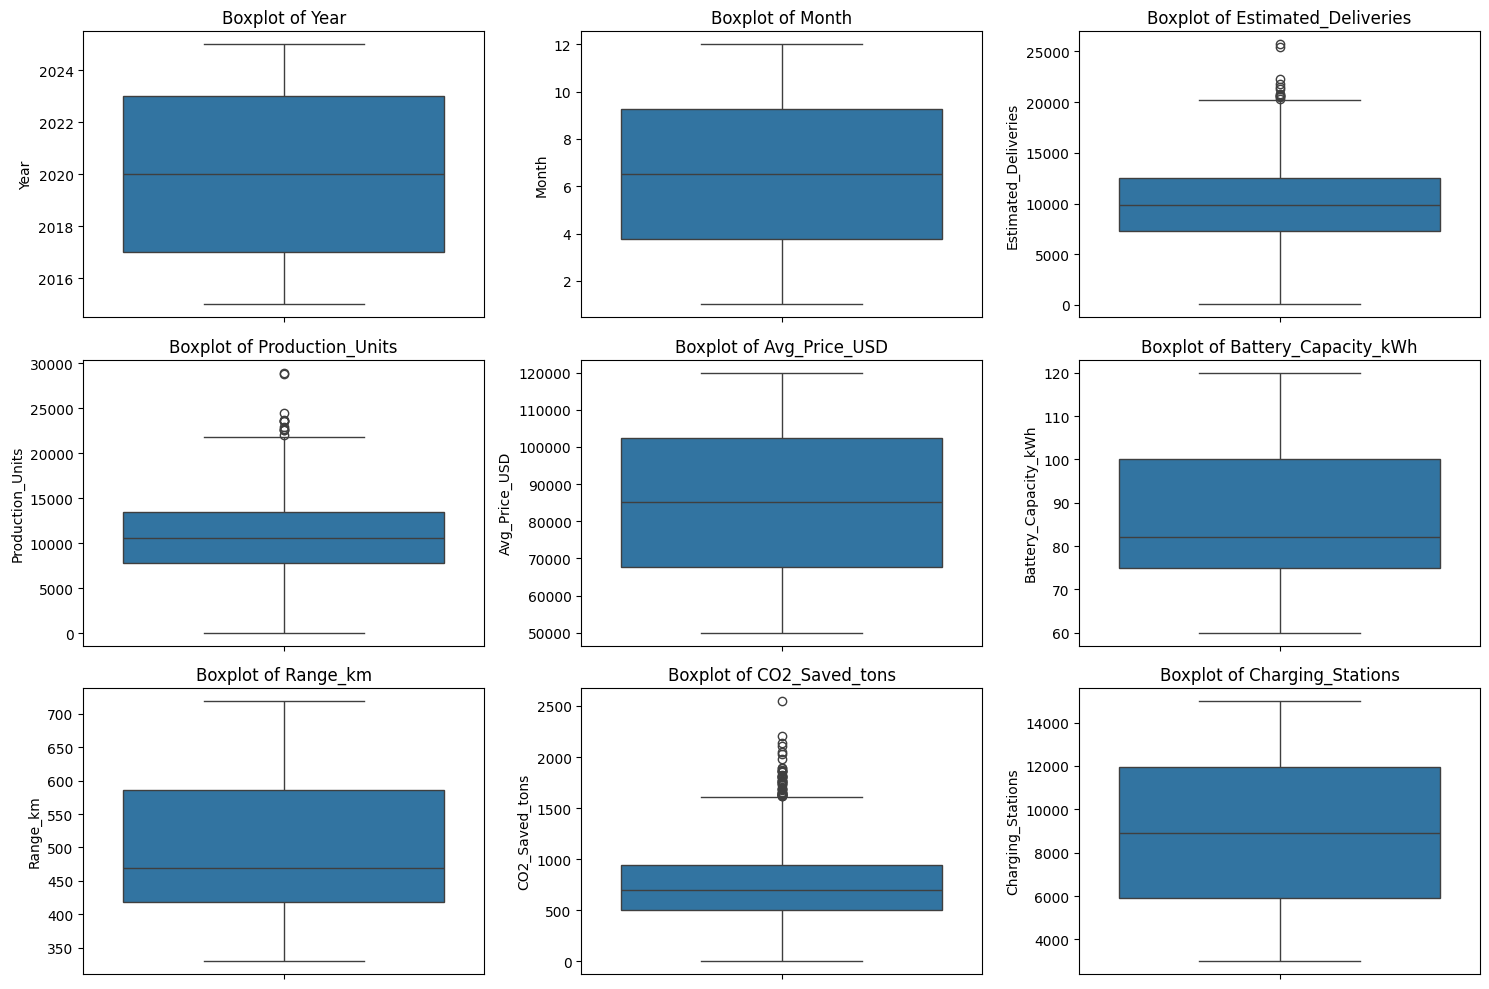

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
# Creating boxplots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


It seems there are outliers in Production_Units and CO2_Saved_tons columns.

In [77]:
#Outliers treatment: Capping

cols_to_treat = ['Production_Units', 'CO2_Saved_tons']
for col in cols_to_treat:
  #calculate 5th and 95th percentiles
  lower_bound = df[col].quantile(0.05)
  upper_bound = df[col].quantile(0.95)

  #cap the outliers
  df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
  print(f"Capped '{col}' at lower bound: {lower_bound:.2f} and upper bound: {upper_bound:.2f}")

print("\nOutliers treated in 'Production_Units' and 'CO2_Saved_tons' columns.")

Capped 'Production_Units' at lower bound: 3569.90 and upper bound: 17675.20
Capped 'CO2_Saved_tons' at lower bound: 233.09 and upper bound: 1389.56

Outliers treated in 'Production_Units' and 'CO2_Saved_tons' columns.


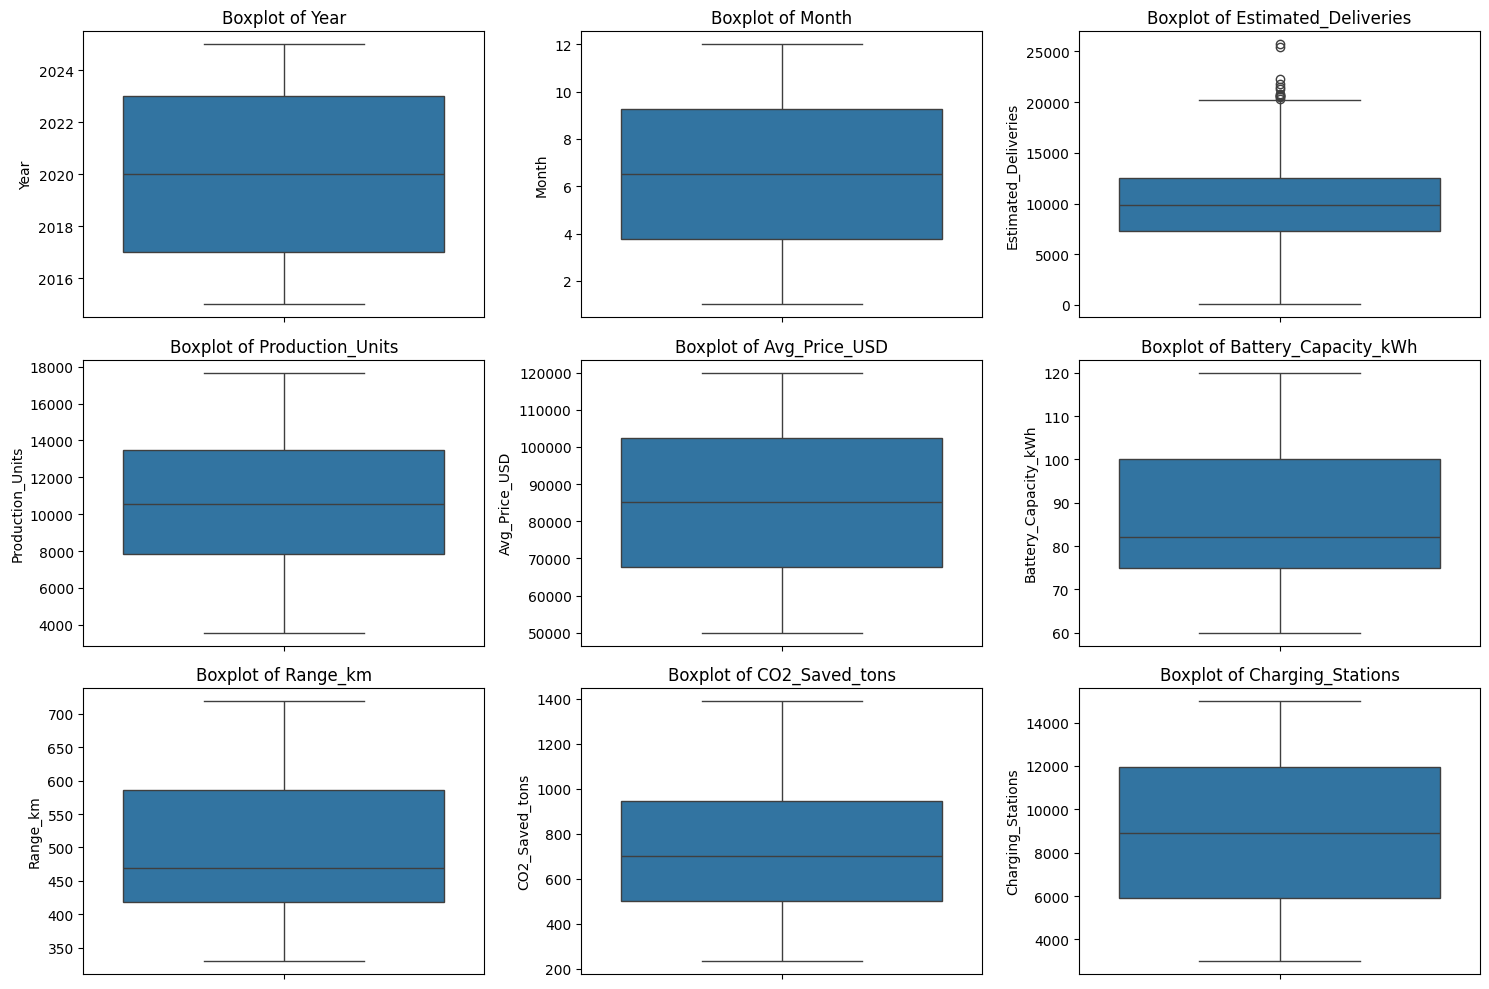

In [78]:
import matplotlib.pyplot as plt

# Creating boxplots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Bivariate analysis

1. Which region has the highest deliveries?

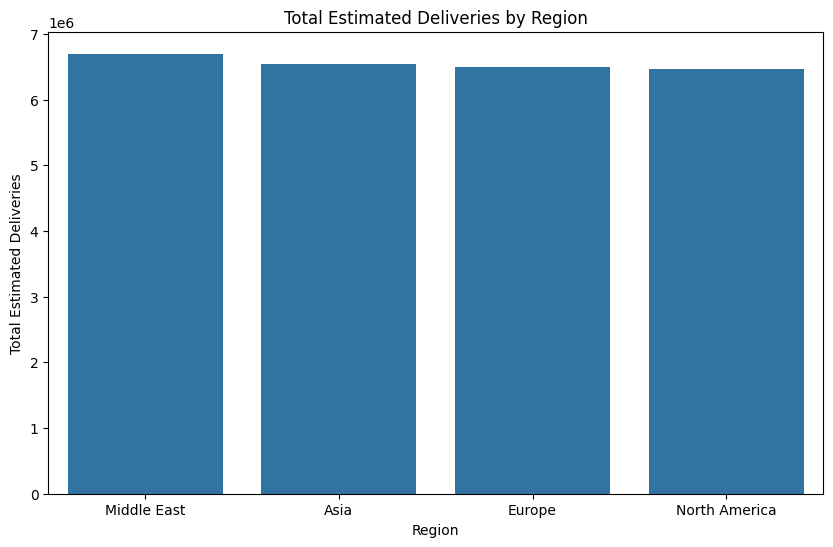

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Region and sum Estimated_Deliveries
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Estimated_Deliveries', data=region_deliveries)
plt.title('Total Estimated Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Estimated Deliveries')
plt.show()

Middle East has highest deliveries.

2. Which model is most popular?

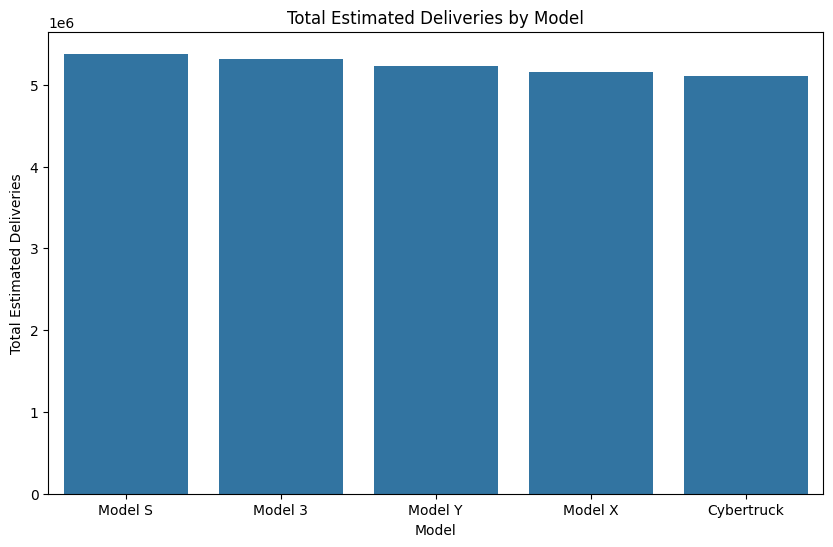

In [80]:
#group by Model and sum of Estimated_Deliveries
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending =False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Estimated_Deliveries', data=model_deliveries)
plt.title('Total Estimated Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Total Estimated Deliveries')
plt.show()

Model S is most popular

3. Does production affect deliveries?

Text(0, 0.5, 'Estimated Deliveries')

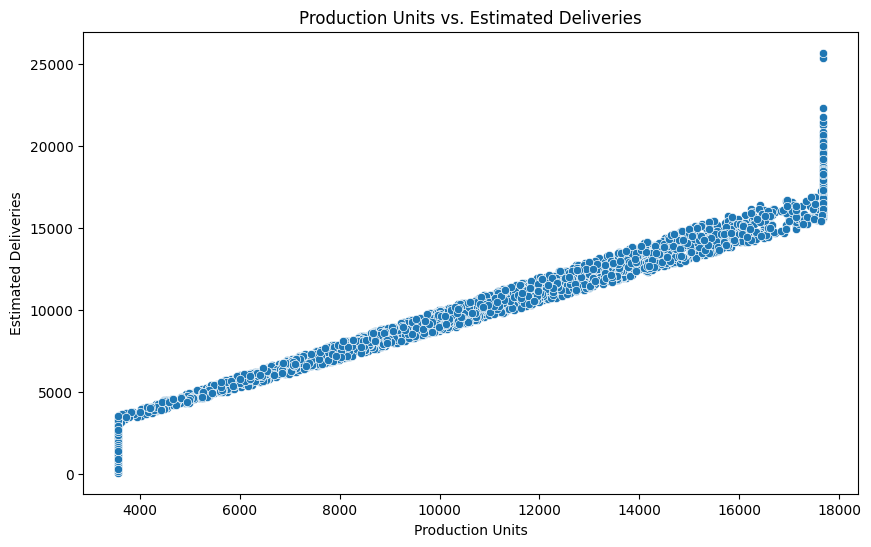

In [81]:
# Scatter plot between Production_Units and Estimated_Deliveries
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Production_Units', y='Estimated_Deliveries', data=df)
plt.title('Production Units vs. Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')

From the scatter plot, as the production increases, the deliveries also raising.

4. Does price affect demand?

Correlation between Average Price (USD) and Estimated Deliveries: -0.03


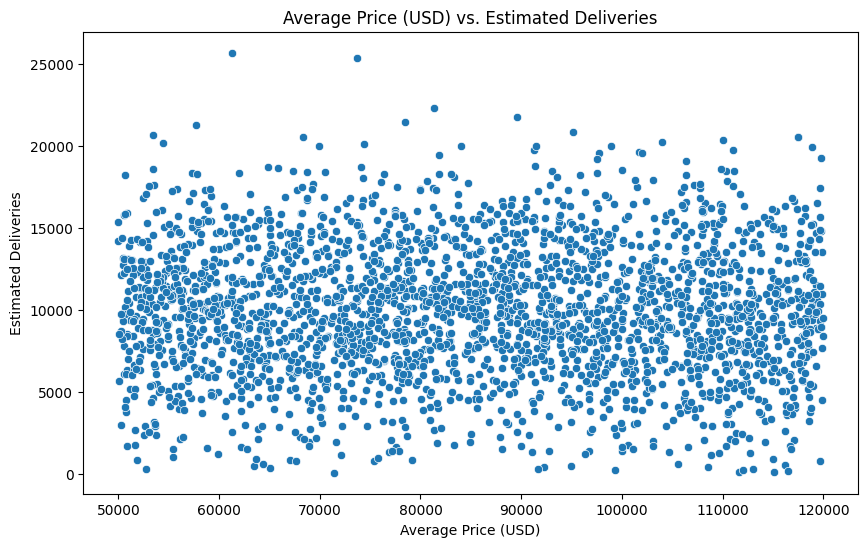

In [82]:
# Scatter plot between Avg_Price_USD and Estimated_Deliveries
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Avg_Price_USD', y='Estimated_Deliveries', data=df)
plt.title('Average Price (USD) vs. Estimated Deliveries')
plt.xlabel('Average Price (USD)')
plt.ylabel('Estimated Deliveries')


# Calculate correlation coefficient
correlation_price_deliveries = df['Avg_Price_USD'].corr(df['Estimated_Deliveries'])
print(f"Correlation between Average Price (USD) and Estimated Deliveries: {correlation_price_deliveries:.2f}")

The plot and correlation calculation says, as the average price slightly increases, the estimated deliveries tend to slightly decrease, and vice-versa.

The absolute value (0.03) is very close to zero, meaning that price explains very little of the variation in deliveries.

It suggests that price, within the observed range, does not have a significant linear impact on the estimated deliveries.

5. Does charging infrastructure affect deliveries?

Correlation between Charging Stations and Estimated Deliveries: 0.00


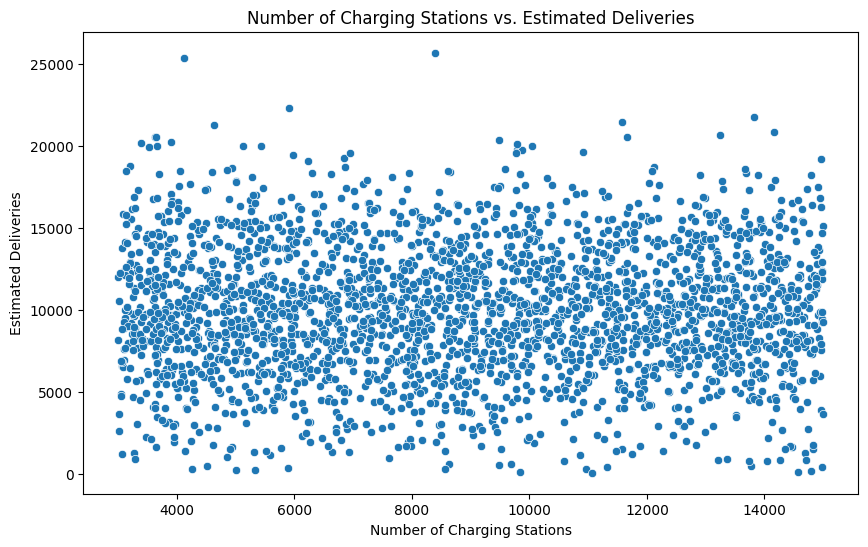

In [83]:
# Scatter plot between Charging_Stations and Estimated_Deliveries
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Charging_Stations', y='Estimated_Deliveries', data=df)
plt.title('Number of Charging Stations vs. Estimated Deliveries')
plt.xlabel('Number of Charging Stations')
plt.ylabel('Estimated Deliveries')

# Calculate correlation coefficient
correlation_charging_deliveries = df['Charging_Stations'].corr(df['Estimated_Deliveries'])
print(f"Correlation between Charging Stations and Estimated Deliveries: {correlation_charging_deliveries:.2f}")

It seems that charging infrastructure, as measured by Charging_Stations, does not have a linear impact on estimated deliveries.

# Correlation Analysis
To identify strongest predictors

In [84]:
import numpy as np

# Calculate correlation with Estimated_Deliveries for each potential predictor
correlation_production_units = df['Estimated_Deliveries'].corr(df['Production_Units'])
correlation_charging_stations = df['Estimated_Deliveries'].corr(df['Charging_Stations'])
correlation_range_km = df['Estimated_Deliveries'].corr(df['Range_km'])
correlation_avg_price_usd = df['Estimated_Deliveries'].corr(df['Avg_Price_USD'])
correlation_year = df['Estimated_Deliveries'].corr(df['Year'])
correlation_month = df['Estimated_Deliveries'].corr(df['Month'])
correlation_battery_capacity = df['Estimated_Deliveries'].corr(df['Battery_Capacity_kWh'])

# Print the correlation coefficients
print(f"Correlation between Estimated Deliveries and Production Units: {correlation_production_units:.2f}")
print(f"Correlation between Estimated Deliveries and Charging Stations: {correlation_charging_stations:.2f}")
print(f"Correlation between Estimated Deliveries and Range_km: {correlation_range_km:.2f}")
print(f"Correlation between Estimated Deliveries and Average Price (USD): {correlation_avg_price_usd:.2f}")
print(f"Correlation between Estimated Deliveries and Year: {correlation_year:.2f}")
print(f"Correlation between Estimated Deliveries and Month: {correlation_month:.2f}")
print(f"Correlation between Estimated Deliveries and Battery_capacity: {correlation_battery_capacity:.2f}")


Correlation between Estimated Deliveries and Production Units: 0.98
Correlation between Estimated Deliveries and Charging Stations: 0.00
Correlation between Estimated Deliveries and Range_km: -0.01
Correlation between Estimated Deliveries and Average Price (USD): -0.03
Correlation between Estimated Deliveries and Year: -0.00
Correlation between Estimated Deliveries and Month: 0.03
Correlation between Estimated Deliveries and Battery_capacity: -0.01


Based on the correlation coefficients, Production_Units has the strongest relationship with Estimated_Deliveries, with a correlation of 0.98.

# Time Trend Analysis

1. Are deliveries increasing every year?

Text(0, 0.5, 'Total Estimated Deliveries')

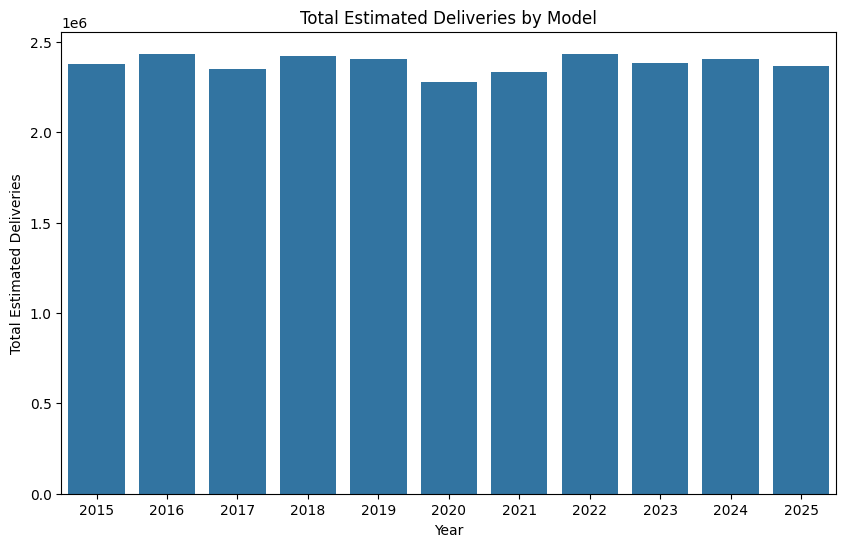

In [85]:
#group by year and sum of Estimated_Deliveries
year_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum().sort_values(ascending =False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Estimated_Deliveries', data=year_deliveries)
plt.title('Total Estimated Deliveries by Model')
plt.xlabel('Year')
plt.ylabel('Total Estimated Deliveries')

2. Which years saw major growth?

  2016, 2018, 2022, 2024

3. Is there seasonality (monthly pattern)?

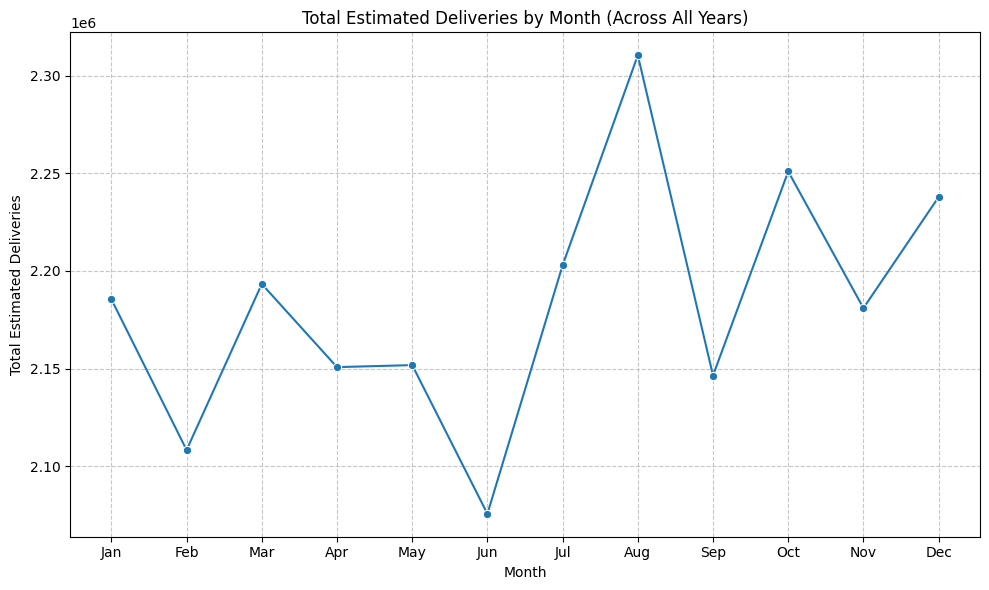

In [86]:
# Group by Month and sum Estimated_Deliveries (across all years)
deliveries_by_month = df.groupby('Month')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Month', y='Estimated_Deliveries', data=deliveries_by_month, marker='o')
plt.title('Total Estimated Deliveries by Month (Across All Years)')
plt.xlabel('Month')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Feature Engineering**

### Creating New Features

In [87]:
# Create a 'Quarter' feature from the 'Month' column
df['Quarter'] = df['Month'].apply(lambda x: (x - 1) // 3 + 1)

# Create a 'Price_Per_Range' feature (Avg_Price_USD per km of range)
df['Price_Per_Range'] = df['Avg_Price_USD'] / df['Range_km']

print("New features 'Quarter' and 'Price_Per_Range' created.")
display(df.head())

New features 'Quarter' and 'Price_Per_Range' created.


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Price_Per_Range
0,2023,5,Europe,Model S,17646,17675.2,92874.27,120,704,1389.557,Interpolated (Month),12207,2,131.923679
1,2015,2,Asia,Model X,3797,4164.0,62205.65,75,438,249.460,Official (Quarter),7640,1,142.022032
2,2019,1,North America,Model X,8411,9189.0,117887.32,82,480,605.590,Interpolated (Month),14071,1,245.598583
3,2021,2,North America,Model 3,6555,7311.0,89294.91,120,712,700.070,Official (Quarter),9333,1,125.414199
4,2016,12,Middle East,Model Y,12374,13537.0,114846.78,120,661,1226.880,Estimated (Region),8722,4,173.747020


The 'Quarter' feature groups the months into standard three-month periods (e.g., Q1 for Jan-Mar, Q2 for Apr-Jun, etc.). This can be useful for capturing seasonality or trends that occur on a quarterly basis.

The 'Price_Per_Range' feature represents the average price of a vehicle per kilometer of its range

# Feature selection

From the correlations, we can see that `Production_Units` has a very strong positive correlation with `Estimated_Deliveries`. Other features show much weaker correlations.

Correlation analysis revealed that Production_Units has the strongest positive relationship with Estimated_Deliveries. However, feature selection was not based solely on correlation values. Additional variables such as vehicle price, battery capacity, driving range, charging infrastructure, region, model, and source type were retained because they may contribute useful predictive information and capture nonlinear relationships that tree-based models can learn.

# one-hot encoding

In [88]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in 'Region', 'Model', 'Source_Type':
  df[col] = encoder.fit_transform(df[col])
df.head(5)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Price_Per_Range
0,2023,5,1,2,17646,17675.2,92874.27,120,704,1389.557,1,12207,2,131.923679
1,2015,2,0,3,3797,4164.0,62205.65,75,438,249.460,2,7640,1,142.022032
2,2019,1,3,3,8411,9189.0,117887.32,82,480,605.590,1,14071,1,245.598583
3,2021,2,3,1,6555,7311.0,89294.91,120,712,700.070,2,9333,1,125.414199
4,2016,12,2,4,12374,13537.0,114846.78,120,661,1226.880,0,8722,4,173.747020


# **Modeling**

In [89]:
#Define x and y
x = df.drop(['Estimated_Deliveries'], axis=1)  #input columns
y = df['Estimated_Deliveries']  #target column
x

,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Price_Per_Range
0,2023,5,1,2,17675.2,92874.27,120,704,1389.5570,1,12207,2,131.923679
1,2015,2,0,3,4164.0,62205.65,75,438,249.4600,2,7640,1,142.022032
2,2019,1,3,3,9189.0,117887.32,82,480,605.5900,1,14071,1,245.598583
3,2021,2,3,1,7311.0,89294.91,120,712,700.0700,2,9333,1,125.414199
4,2016,12,2,4,13537.0,114846.78,120,661,1226.8800,0,8722,4,173.747020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,2,4,14333.0,113771.10,120,719,1389.5570,2,4273,4,158.235188
2636,2019,7,2,2,17675.2,81889.67,82,487,1336.8100,2,9833,3,168.151273
2637,2019,9,0,2,14839.0,97139.38,100,580,1156.3200,0,13709,3,167.481690
2638,2020,5,0,0,3714.0,69990.57,60,358,233.0905,1,6754,2,195.504385


In [90]:
#split the data into training and testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

Above creates an 80% training set and a 20% test set.

# Linear Regression Model

In [91]:
from sklearn.linear_model import LinearRegression
model_lg = LinearRegression()
model_lg.fit(x_train, y_train)

LinearRegression()

In [92]:
#make predictions
pred_lg = model_lg.predict(x_test)

In [93]:
#Evaluate Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_lg = mean_absolute_error(y_test, pred_lg)
mse_lg = mean_squared_error(y_test, pred_lg)
r2_score_lg = r2_score(y_test, pred_lg)

print(f"Mean absolute error: {mae_lg: .2f}")
print(f"Mean square error: {mse_lg: .2f}")
print(f"r2 score: {r2_score_lg: .2f}")

Mean absolute error:  387.99
Mean square error:  273987.66
r2 score:  0.98


Linear regression model performance analysis:

1) On average, the model's predictions differ from the actual deliveries by approximately 388 vehicles.
2) The model explains 98% of the variation in Estimated Deliveries.

# **DecisionTree Regression model**

In [94]:
from sklearn.tree import DecisionTreeRegressor
model_dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model_dt.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [95]:
pred_dt = model_dt.predict(x_test)

In [96]:
#Evaluate Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_dt = mean_absolute_error(y_test, pred_dt)
mse_dt = mean_squared_error(y_test, pred_dt)
r2_score_dt = r2_score(y_test, pred_dt)

print(f"Mean absolute error: {mae_dt: .2f}")
print(f"Mean square error: {mse_dt: .2f}")
print(f"r2 score: {r2_score_dt: .2f}")

Mean absolute error:  427.33
Mean square error:  349199.44
r2 score:  0.98


Decision Tree model performance analysis:

1) On average, the Decision Tree model's predictions differ from the actual deliveries by approximately 427 vehicles (Mean Absolute Error).
2) The model explains 98% of the variation in Estimated Deliveries (R2 Score).
3) The Mean Squared Error of 349199.44 indicates the average squared difference between the predicted and actual values. This metric penalizes larger errors more heavily.

# **RandomForest Regression model**

In [97]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model_rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [98]:
pred_rf = model_rf.predict(x_test)

In [99]:
#Evaluate Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_rf = mean_absolute_error(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf)
r2_score_rf = r2_score(y_test, pred_rf)

print(f"Mean absolute error: {mae_rf: .2f}")
print(f"Mean square error: {mse_rf: .2f}")
print(f"r2 score: {r2_score_rf: .2f}")

Mean absolute error:  374.60
Mean square error:  255649.36
r2 score:  0.98


Random Forest model performance analysis:

1) On average, the Random Forest model's predictions differ from the actual deliveries by approximately 375 vehicles (Mean Absolute Error).
2) The model explains 98% of the variation in Estimated Deliveries (R2 Score).
3) The Mean Squared Error of 255649.36 indicates the average squared difference between the predicted and actual values. This metric penalizes larger errors more heavily.

# **GradientBoosting Regression model**

In [100]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_gb.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [101]:
#make predictions
pred_gb = model_gb.predict(x_test)

In [102]:
#Evaluate Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_gb = mean_absolute_error(y_test, pred_gb)
mse_gb = mean_squared_error(y_test, pred_gb)
r2_score_gb = r2_score(y_test, pred_gb)

print(f"Mean absolute error: {mae_gb: .2f}")
print(f"Mean square error: {mse_gb: .2f}")
print(f"r2 score: {r2_score_gb: .2f}")

Mean absolute error:  373.76
Mean square error:  222118.69
r2 score:  0.99


Gradient Boosting model performance analysis:

1) On average, the Gradient Boosting model's predictions differ from the actual deliveries by approximately 373.76 vehicles (Mean Absolute Error).
2) The model explains 99% of the variation in Estimated Deliveries (R2 Score).
3) The Mean Squared Error of 222118.69 indicates the average squared difference between the predicted and actual values. This metric penalizes larger errors more heavily.

## Model Comparison

In [103]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_lg, mae_dt, mae_rf, mae_gb],
    'MSE': [mse_lg, mse_dt, mse_rf, mse_gb],
    'R2 Score': [r2_score_lg, r2_score_dt, r2_score_rf, r2_score_gb]
})

print("Model Performance Comparison:")
display(model_comparison.sort_values(by='MAE'))

Model Performance Comparison:


,Model,MAE,MSE,R2 Score
3,Gradient Boosting,373.761825,222118.690816,0.985099
2,Random Forest,374.595455,255649.364013,0.982850
0,Linear Regression,387.989744,273987.655817,0.981619
1,Decision Tree,427.332870,349199.441418,0.976574


Based on the comparison:

*   **Gradient Boosting** has the lowest Mean Absolute Error (MAE) and Mean Squared Error (MSE), and the highest R2 Score, indicating it is the best-performing model among the four for this dataset.
*   **Random Forest** is also a strong performer, very close to Gradient Boosting in terms of metrics.
*   **Linear Regression** performed reasonably well, but slightly worse than the ensemble methods.
*   **Decision Tree** had the highest MAE and MSE, suggesting it performed the least accurately compared to the other models, likely due to its simplicity or specific hyperparameter settings.

# **Hyperparameter Tuning**

In [104]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}

# Initialize the GradientBoostingRegressor model
gb_model = GradientBoostingRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_absolute_error')

# Fit GridSearchCV to the training data
grid_search.fit(x_train, y_train)

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best MAE found (negative because GridSearchCV minimizes negative MAE): {-grid_search.best_score_:.2f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best MAE found (negative because GridSearchCV minimizes negative MAE): 365.61


In [105]:
# Get the best model from GridSearchCV
best_gb_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
pred_gb_tuned = best_gb_model.predict(x_test)

# Evaluate the performance of the tuned model
mae_gb_tuned = mean_absolute_error(y_test, pred_gb_tuned)
mse_gb_tuned = mean_squared_error(y_test, pred_gb_tuned)
r2_score_gb_tuned = r2_score(y_test, pred_gb_tuned)

print(f"Tuned Gradient Boosting Model Performance:")
print(f"Mean Absolute Error: {mae_gb_tuned:.2f}")
print(f"Mean Squared Error: {mse_gb_tuned:.2f}")
print(f"R2 Score: {r2_score_gb_tuned:.2f}")

Tuned Gradient Boosting Model Performance:
Mean Absolute Error: 330.92
Mean Squared Error: 196329.23
R2 Score: 0.99


## Tuned vs. Untuned Gradient Boosting Model Performance

In [106]:
tuning_comparison = pd.DataFrame({
    'Model': ['Gradient Boosting (Untuned)', 'Gradient Boosting (Tuned)'],
    'MAE': [mae_gb, mae_gb_tuned],
    'MSE': [mse_gb, mse_gb_tuned],
    'R2 Score': [r2_score_gb, r2_score_gb_tuned]
})

print("Gradient Boosting Model Performance Comparison (Before vs. After Tuning):")
display(tuning_comparison)

Gradient Boosting Model Performance Comparison (Before vs. After Tuning):


,Model,MAE,MSE,R2 Score
0,Gradient Boosting (Untuned),373.761825,222118.690816,0.985099
1,Gradient Boosting (Tuned),330.919348,196329.227092,0.986829


From the table, hyperparameter tuning has improved the Gradient Boosting model's performance:

*   **Mean Absolute Error (MAE)**: Decreased from **373.76** to **330.92**, indicating that, on average, the tuned model's predictions are closer to the actual values.
*   **Mean Squared Error (MSE)**: Decreased from **222118.69** to **196329.23**, showing a reduction in larger errors.
*   **R2 Score**: Increased slightly from **0.99** to **0.99**, meaning the tuned model explains a marginally higher proportion of the variance in the target variable.

# **Feature importance**

In [107]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': best_gb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
4       Production_Units    0.981465
8         CO2_Saved_tons    0.006583
7               Range_km    0.004782
12       Price_Per_Range    0.001814
5          Avg_Price_USD    0.001578
10     Charging_Stations    0.001011
0                   Year    0.000914
1                  Month    0.000538
3                  Model    0.000407
6   Battery_Capacity_kWh    0.000400
2                 Region    0.000277
9            Source_Type    0.000167
11               Quarter    0.000065


Interpretation:

1) Production_Units contributes 98.15% of the predictive power.
2) All other features together contribute only about 1.85%.
3) This means your model is making predictions primarily based on Production_Units.

# Actual vs Predicted Analysis

In [108]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred_gb_tuned
})

print(comparison.head(10))

      Actual     Predicted
2005    6991   7386.094615
32      9326   9534.452376
962     9061   8879.948961
1461    8951   9442.528691
478     8707   8852.232740
1272   11351  11640.946616
211    14193  14311.013890
1309   15156  14606.231609
1745    9915  10252.180377
1498    7642   7962.256319


# Residual analysis

In [109]:
comparison['Error'] = comparison['Actual'] - comparison['Predicted']

print(comparison.head(10))

      Actual     Predicted       Error
2005    6991   7386.094615 -395.094615
32      9326   9534.452376 -208.452376
962     9061   8879.948961  181.051039
1461    8951   9442.528691 -491.528691
478     8707   8852.232740 -145.232740
1272   11351  11640.946616 -289.946616
211    14193  14311.013890 -118.013890
1309   15156  14606.231609  549.768391
1745    9915  10252.180377 -337.180377
1498    7642   7962.256319 -320.256319


## Time Series Forecasting

To perform time series forecasting, we first need to ensure our data has a proper time index. We will create a 'Date' column by combining 'Year' and 'Month', and then set it as the DataFrame's index. After that, we'll aggregate the `Estimated_Deliveries` by this new 'Date' index.

In [110]:
# Create a 'Date' column by combining 'Year' and 'Month'
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))

# Set the 'Date' column as the DataFrame's index
df_ts = df.set_index('Date')

# Aggregate 'Estimated_Deliveries' by date
df_ts_agg = df_ts.groupby(df_ts.index)['Estimated_Deliveries'].sum().to_frame()

print("Time series data prepared and aggregated by date:")
display(df_ts_agg.head())

Time series data prepared and aggregated by date:


,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


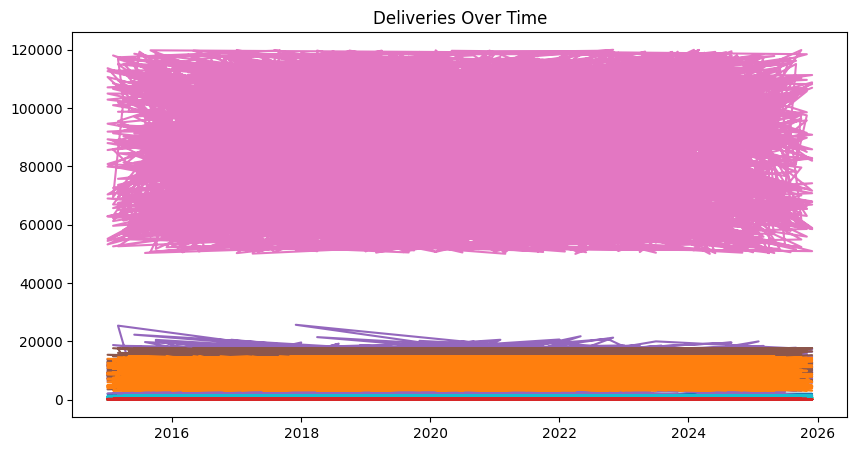

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_ts)
plt.title("Deliveries Over Time")
plt.show()

In [112]:
#Train-Test Split
train = df_ts_agg[:-12]
test = df_ts_agg[-12:]

#Building ARIMA Model

In [113]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(
    train,
    order=(5,1,0)
)

model_fit = model_arima.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [114]:
#Forecast
forecast = model_fit.forecast(
    steps=len(test)
)

print(forecast)

2025-01-01    200817.546824
2025-02-01    200803.184196
2025-03-01    199130.314035
2025-04-01    199816.052192
2025-05-01    200133.846834
2025-06-01    200092.036877
2025-07-01    200271.031327
2025-08-01    200087.921645
2025-09-01    200007.618533
2025-10-01    200055.319974
2025-11-01    200054.504989
2025-12-01    200086.868318
Freq: MS, Name: predicted_mean, dtype: float64


In [115]:
#Evaluate
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    test,
    forecast
)

print("MAE:", mae)

MAE: 10711.655892521812


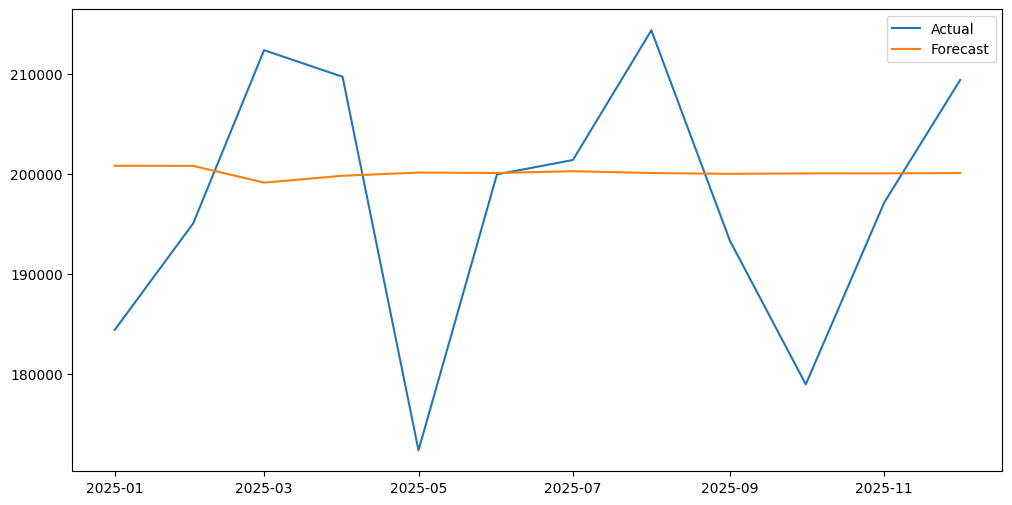

In [116]:
#Plot Actual vs Forecast

plt.figure(figsize=(12,6))

plt.plot(test.index,
         test,
         label='Actual')

plt.plot(test.index,
         forecast,
         label='Forecast')

plt.legend()
plt.show()

Forecast Future Months

Predicts the next 12 months.

In [117]:
model = ARIMA(
    df_ts_agg,
    order=(5,1,0)
)

model_fit = model.fit()

future = model_fit.forecast(
    steps=12
)

print(future)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01    203819.655291
2026-02-01    202894.176208
2026-03-01    199011.662577
2026-04-01    198667.010489
2026-05-01    200971.493839
2026-06-01    201391.449843
2026-07-01    201412.663910
2026-08-01    201031.409119
2026-09-01    200601.086701
2026-10-01    200710.068214
2026-11-01    200864.721560
2026-12-01    200936.680134
Freq: MS, Name: predicted_mean, dtype: float64


# **Business Recommendations**

### Production Planning

Recommendation: Increase production in regions and for models where future demand is expected to grow.

Reason: Forecasting results show rising demand, so producing more vehicles can help meet customer needs and avoid shortages.

### Infrastructure Expansion

Recommendation: Increase charging stations in areas with high EV demand.

Reason: Better charging facilities make EVs more convenient and encourage more people to buy them.

### Pricing Strategy

Recommendation: Study pricing trends for different regions and vehicle models.

Reason: Price may affect sales differently across regions, so better pricing can help increase deliveries.

### Product Strategy

Recommendation: Focus on popular EV models and those offering good value for money.

Reason: Models with strong demand and better price-to-range performance are more likely to attract customers.